# Assignment 3

## A bit of info before you start.


> ***First and foremost, dont use AI to code. Use it to understand and then write code yourself. Use AI to verify if the code you wrote it correct, that will help you learn far far more.***

> ***Implement Stuff from sratch. Use cv2 functions only when numpy implementation can be extremely tedious.***



You will need to use your own image for this assignment, which you need to import into here.
If you cant fetch your image from any APIs that dont need credentials, then :
To preserve an image in Google Colab without a continuous runtime or using Google Drive, you can use base64 string encoding of images ( its really simple )

First, begin by normally uploading the image into the contents folders as you normally do in colab or fetch it using Drive or any API.

To get the base64 string :
```
import base64
with open("your_image.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())
```

Note that the base64 string is a very long string, click on the three dot icon to the left of the current code cell and click on <code> Copy Cell Output </code> to easily copy it to your clipboard.

Then, to embed the string into your Jupyter Notebook :
```
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

# PASTE BASE64 STRING HERE
base64_image = "iVBORw0K..."  # long base64 string

img_data = base64.b64decode(base64_image)
img = Image.open(io.BytesIO(img_data))

plt.imshow(img)
plt.axis("off")
```
The string is really long so, use a multiline string in python ( syntax : """ """ )

Otherwise, you can also choose to use any API ( try researching on https://picsum.photos/ )

## SECTION 1 : Preparations

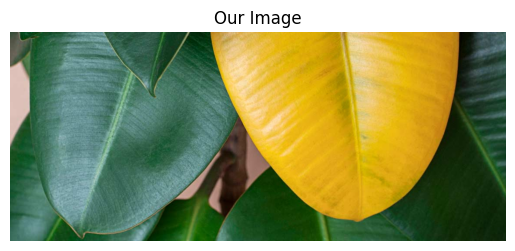

In [ ]:
# @title
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

img_str = """
...
"""

img_data = base64.b64decode(img_str)
img = Image.open(io.BytesIO(img_data))
img_part5 = np.array(img)

plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

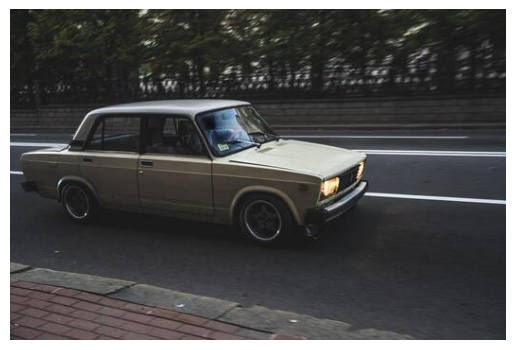

In [ ]:
# @title
base64_image ="""...
"""
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np
import cv2
img_data = base64.b64decode(base64_image)
imgg = Image.open(io.BytesIO(img_data))

plt.imshow(imgg)
plt.axis("off")
plt.show()
myimg = np.array(imgg)

## SECTION 2 : Questions

Embed your own image, the above shown is specifically for last part.

### Part A

#### Task 1 - Convolution
Write a function <code>convolve(img, kernel)</code>
Hint : Lookup <code>np.pad</code> function for padding and research how it works. It takes different modes, one that we want to use is <code>reflect</code>
Also, learn what exactly <code>*</code> does ( particularly if it can convolve matrices of different sizes and if at all you use it, then where you can and where you cannot ). Use it later on for your ease.

#### Task 2 — Average Blur

Implement a function <code>average_blur_gray(img, ksize)</code> using:
* A box kernel of size ksize × ksize
* Only NumPy (no cv2 filtering functions)

Repeat for RGB:

* Apply the kernel on each channel separately.

#### Task 3 - Gaussian Blur

1. Implement a Gaussian kernel generator:
The function signature should be <code>gaussian_kernel(ksize, sigma)</code>
It should return a numpy matrix that is the normalsied gaussian kernel with dimensions ksize x ksize and the 2D gaussian distribution calculation done with standard deviation as sigma. I had talked about it in the lecture, for any queries, research first cuz its not hard to put in values and compute.

2. Convolve it with:
* Gray image
* Each RGB channel

And, then display all results along with the original image.



In [146]:

#PART A task 1;
def convolve(img,ker):
  img = img.astype(np.float64)
  ker = ker.astype(np.float64)
  h,w  = img.shape
  kh,kw = ker.shape
  padh = kh//2
  padw = kw//2
  assert kh % 2 == 1 and kw % 2 == 1
  img = np.pad(img, ((padh, padh), (padw, padw)), mode='reflect')
  ker = np.flip(ker, axis=(0, 1))
  out = np.zeros((h,w))
  for i in range(h):
    for j in range(w):
      for k in range(kh):
        for l in range(kw):
          out[i,j] += img[i+k,j+l] * ker[k,l]
  return out
  #we cannot convolve matrices of different sizes using * directly its giving broadcasting error.if one of the dimensions is 1 then it works


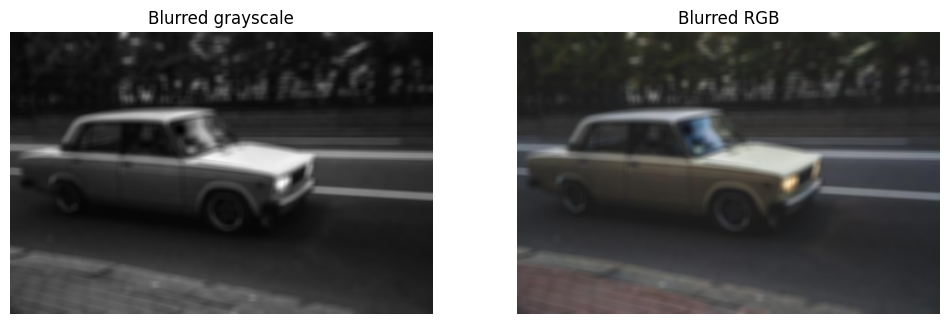

In [147]:
#Task 2
gray = cv2.cvtColor(myimg, cv2.COLOR_RGB2GRAY)
def average_blur_gray(img,ksize):
  ker = np.ones((ksize,ksize))
  ker /= ksize*ksize
  out = convolve(img,ker)
  return out
def average_blur_rgb(img,ksize):
  img = img.astype(np.float64)
  h,w,l = img.shape
  out = np.zeros((h,w,l))
  padh = ksize//2
  ker = np.ones((ksize, ksize), dtype=np.float64)
  ker /= (ksize * ksize)

  for ch in range(3):
        channel = img[:, :, ch]

        padded = np.pad(
            channel,
            ((padh, padh), (padh, padh)),
            mode='reflect'
        )

        for i in range(h):
            for j in range(w):
                patch = padded[i:i+ksize, j:j+ksize]
                out[i, j, ch] = np.sum(patch * ker)

  return out




avgblur = average_blur_gray(gray,9)
avgblurrgb = average_blur_rgb(myimg,9)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(avgblur, cmap='gray')
plt.axis("off")
plt.title("Blurred grayscale")


plt.subplot(1, 2, 2)
plt.imshow(avgblurrgb.astype(np.uint8))
plt.axis("off")
plt.title("Blurred RGB")

plt.show()




In [148]:
#task 3
def gaussian_kernel(ksize,sigma):
  ker = np.zeros((ksize,ksize),dtype = np.float64)
  c = ksize//2
  for i in range(ksize):
    for j in range(ksize):
      x = i-c
      y = j-c
      ker[i,j] =np.exp(-(x*x + y*y) / (2 * sigma * sigma)) #since normalising we dont need the constant part
  ker /= np.sum(ker)
  return ker


In [149]:
def gaussgray(img,ksize):
  ker = gaussian_kernel(ksize,2.0)
  out = convolve(img,ker)
  return out
def gaussrgb(img,ksize):
  img = img.astype(np.float64)
  h,w,l = img.shape
  out = np.zeros((h,w,l))
  padh = ksize//2
  ker = gaussian_kernel(ksize,2.0)

  for ch in range(3):
        channel = img[:, :, ch]

        padded = np.pad(
            channel,
            ((padh, padh), (padh, padh)),
            mode='reflect'
        )

        for i in range(h):
            for j in range(w):
                patch = padded[i:i+ksize, j:j+ksize]
                out[i, j, ch] = np.sum(patch * ker)

  return out



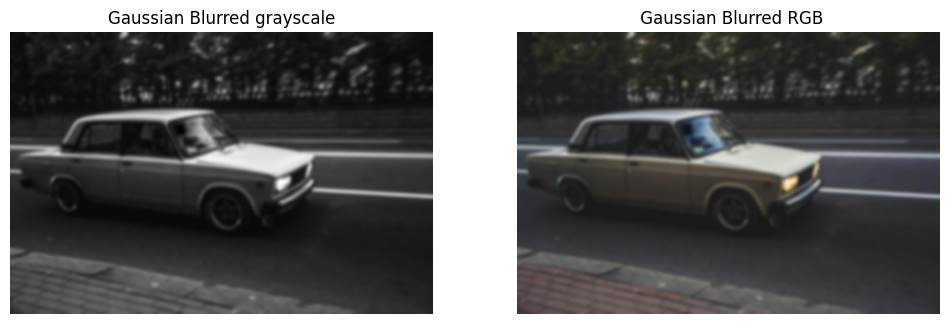

In [150]:
#displaying images
gaussblur = gaussgray(gray,9)
rgb = gaussrgb(myimg,9)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(gaussblur, cmap='gray')
plt.axis("off")
plt.title("Gaussian Blurred grayscale")

plt.subplot(1, 2, 2)
plt.imshow(rgb.astype(np.uint8))
plt.axis("off")
plt.title(" Gaussian Blurred RGB")
plt.show()


### Part B

#### Task - Sobel Edge Detection (NumPy Only)
Implement Sobel X and Sobel Y filters manually using convolution. Apply on the grayscale image.

Compute:
1. Gx
2. Gy
3. Gradient magnitude

Normalize to 0–255 and save the edge map. Threshold if you wish to, if you do then make the thresholding part clear using code comments.

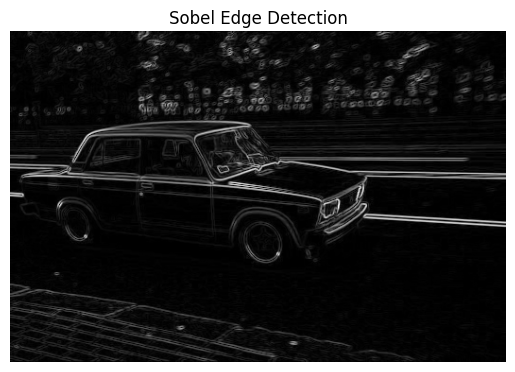

In [151]:
#B.
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float64)

sobel_y =sobel_x.T

Gx = convolve(gray, sobel_x)
Gy = convolve(gray, sobel_y)
mag = np.sqrt(Gx*Gx+Gy*Gy)

norm = mag/np.max(mag)
norm = (norm*255).astype(np.uint8)

#image

plt.imshow(norm, cmap='gray')
plt.axis("off")
plt.title("Sobel Edge Detection")
plt.show()
plt.imsave("sobel_edgemap.png", norm, cmap='gray')



### Part C

#### Task 1 — Laplacian Sharpening ( Only Numpy and Grayscale )
1. Use any 3×3 Laplacian kernel (4-connected or 8-connected).

2. Compute:
* <code>lap = convolve(img, laplacian_kernel)</code>
* <code>sharp = img - lap * alpha</code> where alpha ∈ [0.2, 1].

3. Now, put alpha = 1, if you had chosen a different value earlier. Get a new output. Then use the code in the lecture to do the same using cv2. Now, use python to verify if both numpy with alpha = 1 and cv2 give the exact same output ( Compare the matrices )

#### Task 2 - Unsharp Masking ( Only Numpy and Grayscale )
1. Apply Gaussian blur (from Part 1).
2. Subtract blurred image from original: <code> mask = img - blurred </code>
3. Add scaled mask back: <code>sharp = img + alpha * mask</code> , where you can choose any value of alpha.
4. See how negative values of alpha will give you a blurred image.  



exact match: False


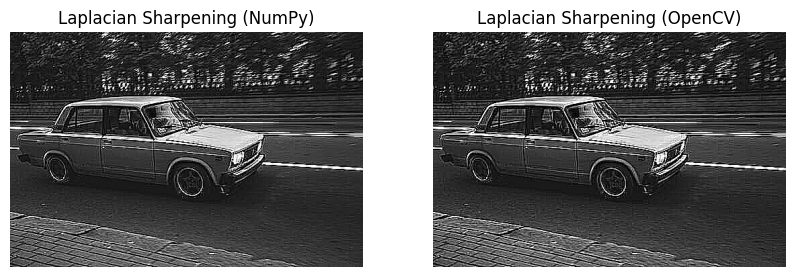

In [152]:
#C task 1
lap_kernel = np.array([
    [1,  1, 1],
    [1, -8, 1],
    [1,  1, 1]
], dtype=np.float64)

lap = convolve(gray, lap_kernel)
alpha = 1
sharp =gray - lap * alpha
sharp = np.clip(sharp, 0, 255).astype(np.uint8)
lap_cv = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
sharp_cv = gray - lap_cv
sharp_cv = np.clip(sharp_cv, 0, 255).astype(np.uint8)
print( "exact match:",np.array_equal(sharp, sharp_cv))
## its giving false because there may be difference in rounding values,different sharpening kernel
##the way we handle boundaries in the convolve function is also different
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sharp, cmap='gray')
plt.axis("off")
plt.title("Laplacian Sharpening (NumPy)")

plt.subplot(1, 2, 2)
plt.imshow(sharp_cv, cmap='gray')
plt.axis("off")
plt.title("Laplacian Sharpening (OpenCV)")

plt.show()



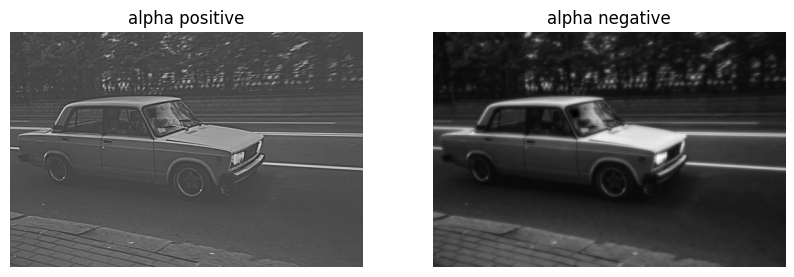

In [153]:
#task 2
mask = gray - gaussblur
alpha = -0.7
sharp2 = gray + alpha* mask
sharp3 = gray + 1.1*mask
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sharp3, cmap='gray')
plt.axis("off")
plt.title("alpha positive")

plt.subplot(1, 2, 2)
plt.imshow(sharp2, cmap='gray')
plt.axis("off")
plt.title("alpha negative")

plt.show()

### Part D

#### Task - Frequency Analysis (LPF & HPF Verification)
Compute the magnitude spectrum of the original image, gaussian blurred image and the unsharp masking image. Now, play with the alpha value in sharpening and gaussian kernel and notice how the magntude spectrum changes.
Then, in code comments, explain your observations of dark and bright areas in the magnitude spectrum. In nutshell, verify how convolution is actually filtering frequencies depending on the kernel.

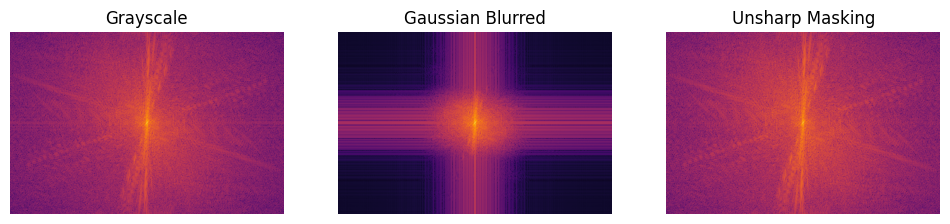

In [156]:
def spectrum(img):
    F = np.fft.fft2(img)
    Fshift = np.fft.fftshift(F)
    mag = np.log1p(np.abs(Fshift))
    return mag
mag_gray = spectrum(gray)
mag_gauss = spectrum(gaussblur)
mag_unsharp = spectrum(sharp3)
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.imshow(mag_gray, cmap='inferno')
plt.axis("off")
plt.title("Grayscale")
plt.subplot(1,3,2)
plt.imshow(mag_gauss, cmap='inferno')
plt.axis("off")
plt.title("Gaussian Blurred")
plt.subplot(1,3,3)
plt.imshow(mag_unsharp,cmap='inferno')
plt.axis("off")
plt.title("Unsharp Masking")
plt.show()
##Gausian blur supresses higher frequencies acts as low pass filter
##unsharping boosts higher frequencies increasing alpha makes edges sharper and hence boosting higher frequencies more

### Part E

#### Task - Custom Colour Kernel (Detect Yellow Leaf Edges)

**Instructions :**
* At the start of the assignment .ipynb file, you will find a code cell in section 1, run it to see an image with a yellow leaf amongst green leaves.
* Design a 3×3 or 5×5 custom kernel applied separately to each channel that highlights the edges where any other colour transitions into a yellowish hue.

**Hints :**

* Yellow = (R high, G high, B low)

* Dark green = (G high, R low, B low)

**Steps:**

1. Analyze the RGB values of green & yellow regions.

2. Create a custom kernel that responds strongly to change from green to yellow in:
* Red matrices of RGB
* Green matrices of RGB
* Optionally R - G difference
* Think about the gradient in Red - Green. Is there a huge change the value of R-G when colour changes from Green to Yellow ? If yes, try to exploit it.

3. Combine the response maps.

4. Get a clean outline around the leaf.

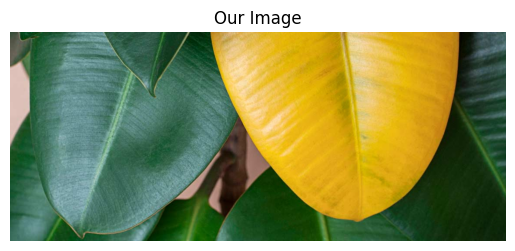

In [157]:
plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

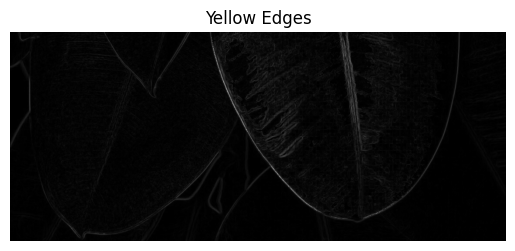

In [158]:
yellow_mask = ((img_part5[:, :, 0] > 150)&(img_part5[:, :, 1] > 150) &(img_part5[:, :, 2] < 120))
R = img_part5[:, :, 0].astype(np.float64)
G = img_part5[:, :, 1].astype(np.float64)
B = img_part5[:, :, 2].astype(np.float64)

Gx_R = convolve(R, sobel_x)
Gy_R = convolve(R, sobel_y)

Gx_G = convolve(G, sobel_x)
Gy_G = convolve(G, sobel_y)

Gx_B = convolve(B, sobel_x)
Gy_B = convolve(B, sobel_y)
  ##gx and gy are from the sobel filters i m just applying sobel to the yellow part

mag = np.sqrt(Gx_R**2 + Gy_R**2 +Gx_G**2 + Gy_G**2 +Gx_B**2 + Gy_B**2)
# soft weighting instead of hard masking i tried different weights to get edges
mag = mag * (0.25 + 0.75 * yellow_mask)
norm = mag/np.max(mag)
norm = (norm*255).astype(np.uint8)


plt.imshow(norm,cmap='gray')
plt.axis("off")
plt.title("Yellow Edges")
plt.show()


### Bonus - Part F

#### Task - Color Manipulation Using Lecture 2 Concepts

**NOTE :** only for this, you can use cv2 functions, no need of doing everything in Numpy. Although there are still more brownie parts for Numpy hardwork.

1. Convert the RGB image to HSV. Use your rgb_to_hsv() from Lecture 2 Assignment - free Numopy points ;)) .
2. Identify pixels belonging to the yellow leaf using an HSV mask. (maybe take help from Part E or design a new hue mask)
3. Now use your full brain and chnage the colour of the leaf to red.

Convert back to RGB.

Display the final result.

For reference, heres the image I expect as a result. And its not actually tough, easy 5 lines code.
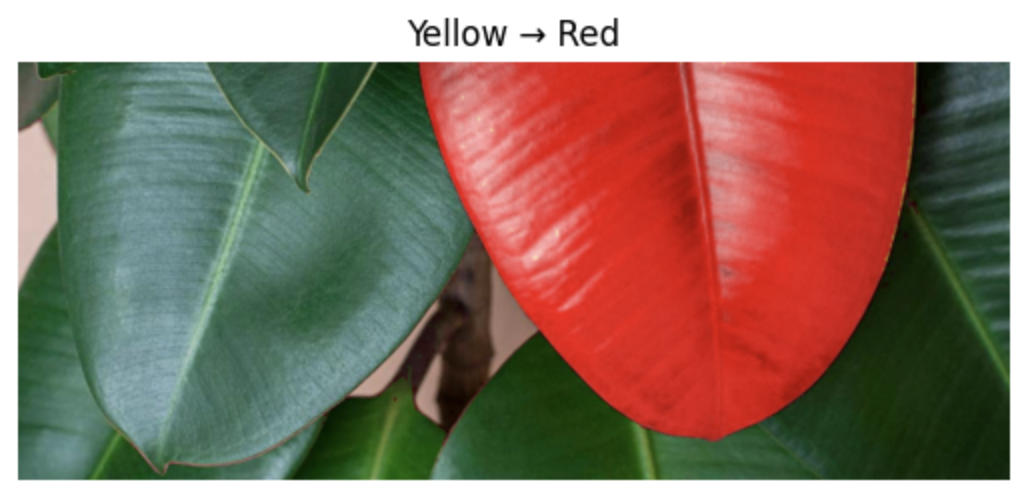

Also, we can change to a less brighter colour
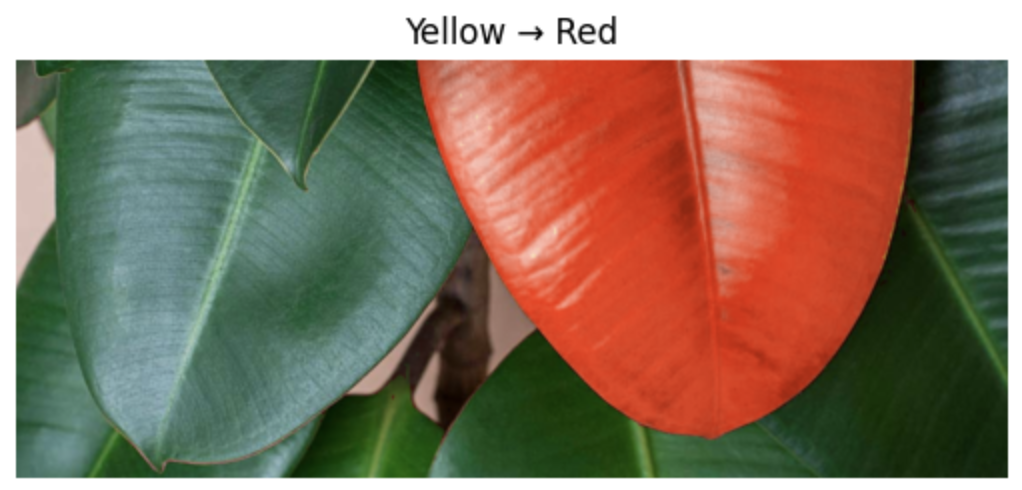

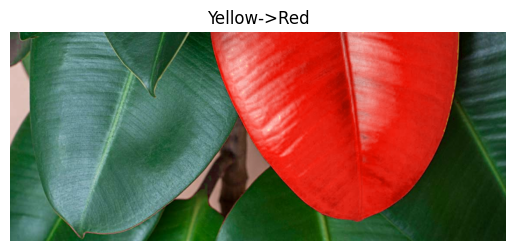

In [155]:
hsv = cv2.cvtColor(img_part5, cv2.COLOR_RGB2HSV)

yellow_mask2 = (hsv[:, :, 0] > 17) & (hsv[:, :, 0] <35)
hsv[yellow_mask2, 0] = 2.0    # red hue
result = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
result = np.clip(result, 0, 255).astype(np.uint8)
plt.imshow(result)
plt.axis("off")
plt.title("Yellow->Red")
plt.show()